# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training images shape :", x_train.shape)   # (50000, 32, 32, 3)
print("Training labels shape :", y_train.shape)   # (50000, 1)
print("Test images shape     :", x_test.shape)    # (10000, 32, 32, 3)
print("Test labels shape     :", y_test.shape)    # (10000, 1)
print("Pixel value range     :", x_train.min(), "to", x_train.max())

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Training images shape : (50000, 32, 32, 3)
Training labels shape : (50000, 1)
Test images shape     : (10000, 32, 32, 3)
Test labels shape     : (10000, 1)
Pixel value range     : 0 to 255


## 🖼️ Visualize Sample Images

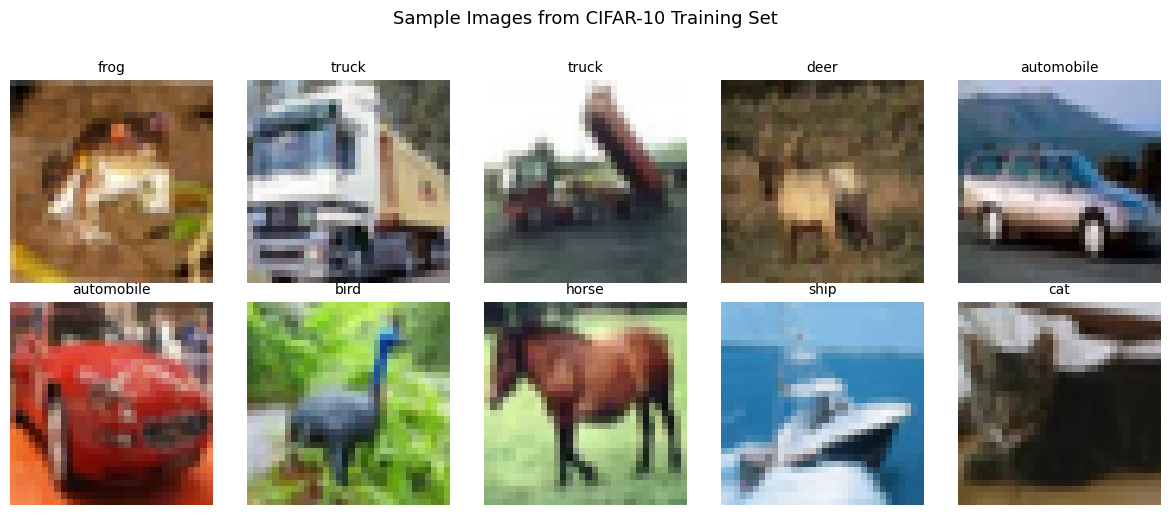

In [3]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]], fontsize=10)
    plt.axis('off')
plt.suptitle('Sample Images from CIFAR-10 Training Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
# Normalize: 0-255 integers  →  0.0-1.0 floats
x_train_norm = x_train / 255.0
x_test_norm  = x_test  / 255.0

# Flatten: (50000, 32, 32, 3)  →  (50000, 3072) for ANN input
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat  = x_test_norm.reshape(len(x_test_norm),  -1)

print("Normalized pixel range :", x_train_norm.min(), "to", x_train_norm.max())
print("Flat shape for ANN     :", x_train_flat.shape)   # 32*32*3 = 3072

Normalized pixel range : 0.0 to 1.0
Flat shape for ANN     : (50000, 3072)


# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='ANN_Model')

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

Model: "ANN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
print("Training ANN for 10 epochs...")

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

Training ANN for 10 epochs...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.2713 - loss: 1.9941 - val_accuracy: 0.3166 - val_loss: 1.8589
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.3191 - loss: 1.8631 - val_accuracy: 0.3642 - val_loss: 1.7826
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.3284 - loss: 1.8350 - val_accuracy: 0.3782 - val_loss: 1.7742
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step - accuracy: 0.3447 - loss: 1.7990 - val_accuracy: 0.3808 - val_loss: 1.7322
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.3514 - loss: 1.7747 - val_accuracy: 0.3808 - val_loss: 1.7431
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.3628 - loss: 1.7558 - val_accuracy: 0.3960 - val_loss: 1.7224
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.3691 - loss: 1.7395 - val_accuracy: 0.3914 - val_loss: 1.7411
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accu

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"ANN  →  Test Loss: {ann_test_loss:.4f}  |  Test Accuracy: {ann_test_acc:.4f} ({ann_test_acc*100:.2f}%)")

ANN  →  Test Loss: 1.6540  |  Test Accuracy: 0.4165 (41.65%)


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [8]:
cnn_model = models.Sequential([
    # Block 1 — detect basic edges and colors
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2 — detect shapes and textures
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3 — detect complex patterns
    layers.Conv2D(128, (3, 3), activation='relu'),

    # Flatten and classify
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_Model')

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,194 (1.36 MB)

 Trainable params: 357,002 (1.36 MB)

 Non-trainable params: 192 (768.00 B)

In [9]:
print("Training CNN for 10 epochs...")

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

Training CNN for 10 epochs...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 130ms/step - accuracy: 0.4614 - loss: 1.5088 - val_accuracy: 0.5254 - val_loss: 1.3492
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.6053 - loss: 1.1250 - val_accuracy: 0.6206 - val_loss: 1.0427
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 132ms/step - accuracy: 0.6691 - loss: 0.9450 - val_accuracy: 0.6636 - val_loss: 0.9574
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.7109 - loss: 0.8337 - val_accuracy: 0.6820 - val_loss: 0.9143
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 129ms/step - accuracy: 0.7418 - loss: 0.7346 - val_accuracy: 0.6516 - val_loss: 1.0863
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.7704 - loss: 0.6517 - val_accuracy: 0.6994 - val_loss: 0.8895
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 131ms/step - accuracy: 0.7899 - loss: 0.5928 - val_accuracy: 0.6690 - val_loss: 1.0367
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/st

In [10]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN  →  Test Loss: {cnn_test_loss:.4f}  |  Test Accuracy: {cnn_test_acc:.4f} ({cnn_test_acc*100:.2f}%)")

CNN  →  Test Loss: 0.9881  |  Test Accuracy: 0.6966 (69.66%)


## 📈 Compare Learning Curves

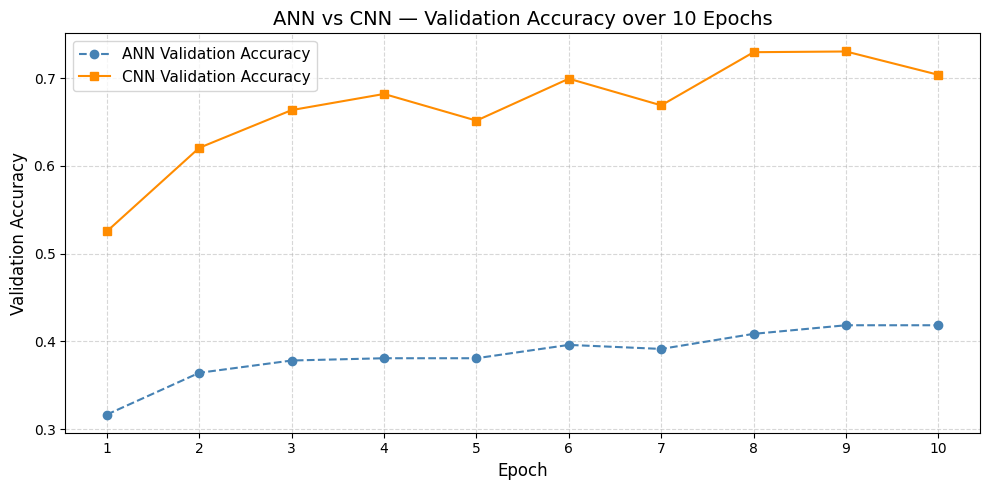

In [11]:
epochs_range = range(1, 11)

plt.figure(figsize=(10, 5))

plt.plot(epochs_range, ann_history.history['val_accuracy'],
         label='ANN Validation Accuracy', marker='o', linestyle='--', color='steelblue')

plt.plot(epochs_range, cnn_history.history['val_accuracy'],
         label='CNN Validation Accuracy', marker='s', linestyle='-', color='darkorange')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('ANN vs CNN — Validation Accuracy over 10 Epochs', fontsize=14)
plt.legend(fontsize=11)
plt.xticks(epochs_range)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [12]:
# Define augmentation pipeline — applied only during training, not during evaluation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name='Data_Augmentation')

# Build the augmented CNN
aug_cnn_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='Augmented_CNN')

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_cnn_model.summary()

Model: "Augmented_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Data_Augmentation (Sequential)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
print("Training Augmented CNN for 10 epochs...")

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"Aug CNN  →  Test Loss: {aug_test_loss:.4f}  |  Test Accuracy: {aug_test_acc:.4f} ({aug_test_acc*100:.2f}%)")

Training Augmented CNN for 10 epochs...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 98s 139ms/step - accuracy: 0.6297 - loss: 1.0678 - val_accuracy: 0.6604 - val_loss: 0.9934
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 136ms/step - accuracy: 0.6302 - loss: 1.0565 - val_accuracy: 0.6422 - val_loss: 1.0398
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 133ms/step - accuracy: 0.6388 - loss: 1.0326 - val_accuracy: 0.6626 - val_loss: 0.9823
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 134ms/step - accuracy: 0.6495 - loss: 1.0111 - val_accuracy: 0.6874 - val_loss: 0.9320
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 134ms/step - accuracy: 0.6485 - loss: 1.0040 - val_accuracy: 0.6506 - val_loss: 1.0375
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 132ms/step - accuracy: 0.6565 - loss: 0.9906 - val_accuracy: 0.6880 - val_loss: 0.8949
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 133ms/step - accuracy: 0.6577 - loss: 0.9791 - val_accuracy: 0.6194 - val_loss: 1.1860
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14

# 📊 Final Comparison Table

In [15]:
comparison_df = pd.DataFrame({
    'Model'         : ['ANN', 'CNN'],
    'Test Accuracy' : [round(ann_test_acc, 4), round(cnn_test_acc, 4)],
    'Test Loss'     : [round(ann_test_loss, 4), round(cnn_test_loss, 4)],
    'Accuracy (%)'  : [round(ann_test_acc * 100, 2), round(cnn_test_acc * 100, 2)]
})

print(comparison_df.to_string(index=False))

Model  Test Accuracy  Test Loss  Accuracy (%)
  ANN         0.4165     1.6540         41.65
  CNN         0.6966     0.9881         69.66


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

---

# 🎓 Student Learning Tasks — Fully Implemented

These tasks are meant to help you go beyond the basics. Each one is explained and coded below.

---

### ✅ Task 1: Increase ANN Dense Layers and Observe Performance

We add one more hidden Dense layer to give the ANN more capacity to learn.  
Adding layers allows the model to learn more complex patterns — but it also trains slower and may overfit.

In [16]:
# Task 1 — Deeper ANN with 3 hidden layers instead of 2
ann_deep = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),   # extra layer added here
    layers.Dense(10, activation='softmax')
], name='ANN_Deep')

ann_deep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training deeper ANN...")
ann_deep_history = ann_deep.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

deep_ann_loss, deep_ann_acc = ann_deep.evaluate(x_test_flat, y_test, verbose=0)
print(f"\nOriginal ANN accuracy : {ann_test_acc:.4f}")
print(f"Deeper ANN accuracy   : {deep_ann_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training deeper ANN...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 40ms/step - accuracy: 0.2475 - loss: 2.0308 - val_accuracy: 0.3136 - val_loss: 1.8797
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 38ms/step - accuracy: 0.3063 - loss: 1.8893 - val_accuracy: 0.3410 - val_loss: 1.8118
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.3256 - loss: 1.8451 - val_accuracy: 0.3520 - val_loss: 1.7942
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 41ms/step - accuracy: 0.3382 - loss: 1.8201 - val_accuracy: 0.3438 - val_loss: 1.8284
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 35ms/step - accuracy: 0.3496 - loss: 1.7888 - val_accuracy: 0.3908 - val_loss: 1.7403
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.3560 - loss: 1.7688 - val_accuracy: 0.3824 - val_loss: 1.7373
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 37ms/step - accuracy: 0.3594 - loss: 1.7534 - val_accuracy: 0.4014 - val_loss: 1.6989
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0

---

### ✅ Task 2: Scale CNN Filters 32 → 64 → 128

The original CNN already uses this pattern.  
Here we confirm and annotate **why** we increase filter count per block:
- **32 filters** in block 1 → detects low-level features (edges, gradients)
- **64 filters** in block 2 → detects mid-level features (corners, shapes)
- **128 filters** in block 3 → detects high-level features (object parts)

More filters = more feature detectors = better learning of complex patterns.

In [17]:
# Task 2 — Explicitly show 32 → 64 → 128 filter scaling
cnn_scaled = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),   # 32 filters
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),                            # 64 filters
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),                           # 128 filters

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_Scaled_Filters')

cnn_scaled.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Filter sizes per conv block: 32 → 64 → 128")
cnn_scaled.summary()

Filter sizes per conv block: 32 → 64 → 128


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Scaled_Filters"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,194 (1.36 MB)

 Trainable params: 357,002 (1.36 MB)

 Non-trainable params: 192 (768.00 B)

---

### ✅ Task 3: Train for 20 Epochs

More epochs = more passes through the training data.  
The model gets more chances to update its weights and improve accuracy.  
However, too many epochs without EarlyStopping can cause **overfitting** — the model memorizes training data but fails on test data.

In [18]:
# Task 3 — Train the scaled CNN for 20 epochs
print("Training CNN for 20 epochs...")

history_20ep = cnn_scaled.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

loss_20ep, acc_20ep = cnn_scaled.evaluate(x_test_norm, y_test, verbose=0)
print(f"\n20-epoch CNN  →  Test Accuracy: {acc_20ep:.4f} ({acc_20ep*100:.2f}%)")

Training CNN for 20 epochs...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 97s 133ms/step - accuracy: 0.4737 - loss: 1.4810 - val_accuracy: 0.5224 - val_loss: 1.3169
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 134ms/step - accuracy: 0.6141 - loss: 1.1069 - val_accuracy: 0.5624 - val_loss: 1.2727
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 131ms/step - accuracy: 0.6739 - loss: 0.9364 - val_accuracy: 0.6370 - val_loss: 1.0535
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 134ms/step - accuracy: 0.7148 - loss: 0.8284 - val_accuracy: 0.6610 - val_loss: 1.0525
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 134ms/step - accuracy: 0.7447 - loss: 0.7288 - val_accuracy: 0.6708 - val_loss: 0.9552
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 133ms/step - accuracy: 0.7734 - loss: 0.6505 - val_accuracy: 0.7174 - val_loss: 0.8304
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 133ms/step - accuracy: 0.7936 - loss: 0.5899 - val_accuracy: 0.7176 - val_loss: 0.8483
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 132m

---

### ✅ Task 4: Add EarlyStopping

**EarlyStopping** is a callback that stops training automatically when performance stops improving.  

- `monitor='val_loss'` — watches validation loss
- `patience=4` — waits 4 extra epochs before stopping, in case it improves
- `restore_best_weights=True` — rolls back to the best weights seen during training

This saves compute time and prevents overfitting.

In [24]:
from tensorflow.keras import callbacks

# Task 4 — CNN with EarlyStopping
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

cnn_es_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_EarlyStopping')

cnn_es_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training with EarlyStopping (max 20 epochs)...")
history_es = cnn_es_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

es_loss, es_acc = cnn_es_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nEarlyStopping CNN  →  Stopped at epoch {len(history_es.epoch)}")
print(f"Test Accuracy      →  {es_acc:.4f} ({es_acc*100:.2f}%)")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with EarlyStopping (max 20 epochs)...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 131ms/step - accuracy: 0.4752 - loss: 1.4740 - val_accuracy: 0.5598 - val_loss: 1.2276
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 132ms/step - accuracy: 0.6066 - loss: 1.1160 - val_accuracy: 0.4976 - val_loss: 1.5281
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 132ms/step - accuracy: 0.6728 - loss: 0.9365 - val_accuracy: 0.6408 - val_loss: 1.0320
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 134ms/step - accuracy: 0.7153 - loss: 0.8177 - val_accuracy: 0.6780 - val_loss: 0.9183
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 132ms/step - accuracy: 0.7453 - loss: 0.7253 - val_accuracy: 0.6734 - val_loss: 0.9987
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 135ms/step - accuracy: 0.7720 - loss: 0.6437 - val_accuracy: 0.6996 - val_loss: 0.8875
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 132ms/step - accuracy: 0.7976 - loss: 0.5766 - val_accuracy: 0.7070 - val_loss: 0.8727
Epoch 8/20
704/704 ━━━━━━━━━━━━━━

---

### ✅ Task 5: Full Data Augmentation Training Run

This is the most complete version of our CNN:
- Data augmentation (RandomFlip, RandomRotation, RandomZoom)
- Scaled filters (32 → 64 → 128)
- BatchNormalization
- EarlyStopping
- 20 epochs maximum

This combination typically gives the best generalization on test data.

In [25]:
from tensorflow.keras import callbacks

# Task 5 — Complete augmented model with all upgrades

augmentation_layer = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

full_aug_model = models.Sequential([
    augmentation_layer,

    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='Full_Augmented_CNN')

full_aug_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_aug = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

print("Training Full Augmented CNN (up to 20 epochs with EarlyStopping)...")
full_aug_history = full_aug_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_aug],
    verbose=1
)

full_aug_loss, full_aug_acc = full_aug_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nFull Augmented CNN  →  Test Accuracy: {full_aug_acc:.4f} ({full_aug_acc*100:.2f}%)")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Full Augmented CNN (up to 20 epochs with EarlyStopping)...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 112s 151ms/step - accuracy: 0.4132 - loss: 1.7213 - val_accuracy: 0.5070 - val_loss: 1.4281
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 105s 149ms/step - accuracy: 0.5219 - loss: 1.3578 - val_accuracy: 0.5774 - val_loss: 1.1993
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 105s 149ms/step - accuracy: 0.5643 - loss: 1.2421 - val_accuracy: 0.5972 - val_loss: 1.1740
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 147ms/step - accuracy: 0.5905 - loss: 1.1635 - val_accuracy: 0.5728 - val_loss: 1.2823
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 104s 147ms/step - accuracy: 0.6158 - loss: 1.1037 - val_accuracy: 0.6596 - val_loss: 0.9829
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 104s 148ms/step - accuracy: 0.6341 - loss: 1.0587 - val_accuracy: 0.6174 - val_loss: 1.1416
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 149ms/step - accuracy: 0.6475 - loss: 1.0128 - val_accuracy: 0.6026 - val_loss: 1.1826
Epoch 8/

---

## 📊 Final Summary: All Model Comparison

Let's put every model we built into one comparison table.

In [26]:
final_comparison = pd.DataFrame({
    'Model'            : ['ANN (Baseline)', 'CNN (Baseline)', 'Augmented CNN', 'Full Aug + EarlyStopping'],
    'Test Accuracy'    : [
                            round(ann_test_acc, 4),
                            round(cnn_test_acc, 4),
                            round(aug_test_acc, 4),
                            round(full_aug_acc, 4)
                         ],
    'Accuracy (%)'     : [
                            round(ann_test_acc * 100, 2),
                            round(cnn_test_acc * 100, 2),
                            round(aug_test_acc * 100, 2),
                            round(full_aug_acc * 100, 2)
                         ]
})

print(final_comparison.to_string(index=False))

                   Model  Test Accuracy  Accuracy (%)
          ANN (Baseline)         0.4165         41.65
          CNN (Baseline)         0.6966         69.66
           Augmented CNN         0.6902         69.02
Full Aug + EarlyStopping         0.7065         70.65


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**